# Problem2


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## InventoryEnv

In [10]:
class InventoryEnv:
    def __init__(self, T=100, I_max=50, Q_max=25, K=100, C=3, H=5, P=20, L=15):
        self.T = T
        self.I_max = I_max
        self.Q_max = Q_max
        self.K = K
        self.C = C
        self.H = H
        self.P = P
        self.L = L

        self.state_dim = 2
        self.state_space = [(t, I) for t in range(self.T + 1) for I in range(self.I_max + 1)]
        self.terminal_states = [(self.T, I) for I in range(self.I_max + 1)]

        self.action_dim = self.Q_max + 1
        self.action_space = [q for q in range(self.Q_max + 1)]

    def reset(self):
        self.state = (0, 0)
        return np.array(self.state, dtype=np.float32)

    def step(self, action):
        t, I = self.state
        q = min(action, self.I_max - I)
        I_opening = I + q
        D = np.random.poisson(self.L)
        sales = min(I_opening, D)
        lost_sales = max(D - I_opening, 0)
        I_closing = max(I_opening - D, 0)

        if q > 0:
            order_cost = self.K + self.C * q
        else:
            order_cost = 0

        holding_cost = self.H * I_closing
        penalty_cost = self.P * lost_sales
        total_cost = order_cost + holding_cost + penalty_cost
        reward = -total_cost

        self.state = (t + 1, I_closing)
        done = self.state in self.terminal_states

        return np.array(self.state, dtype=np.float32), reward, done

## (1) Q-Network

- Hidden layers: 2
- Hidden nodes: 128
- Activation: ReLU
- Optimizer: Adam
- Learning rate: 0.001

In [3]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, s):
        return self.net(s)

## (2) Replay Buffer

In [4]:
class ReplayBuffer:
    def __init__(self, state_dim, max_size=10000):
        self.max_size = max_size
        self.count = 0
        self.size = 0

        self.s = np.zeros((max_size, state_dim), dtype=np.float32)
        self.a = np.zeros((max_size, 1), dtype=np.int64)
        self.r = np.zeros((max_size, 1), dtype=np.float32)
        self.s_next = np.zeros((max_size, state_dim), dtype=np.float32)
        self.done = np.zeros((max_size, 1), dtype=np.float32)

    def store(self, s, a, r, s_next, done):
        self.s[self.count] = s
        self.a[self.count] = a
        self.r[self.count] = r
        self.s_next[self.count] = s_next
        self.done[self.count] = float(done)

        self.count = (self.count + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size):
        idx = np.random.choice(self.size, size=batch_size, replace=False)
        return (
            torch.tensor(self.s[idx]).to(device),
            torch.tensor(self.a[idx], dtype=torch.long).to(device),
            torch.tensor(self.r[idx]).to(device),
            torch.tensor(self.s_next[idx]).to(device),
            torch.tensor(self.done[idx]).to(device)
        )

## (3) DQN Learning 모형

In [5]:
class DQN_Learning:
    def __init__(self, state_dim, action_dim, batch_size=128, gamma=0.99, alpha=0.001, K=100):
        self.state_dim = state_dim
        self.action_dim = action_dim

        # Current network & Target network
        self.q = DQN(state_dim, action_dim).to(device)
        self.q_target = DQN(state_dim, action_dim).to(device)
        self.q_target.load_state_dict(self.q.state_dict())  # theta- <- theta
        self.q_target.eval()

        self.optimizer = optim.Adam(self.q.parameters(), lr=alpha)
        self.loss_fn = nn.MSELoss()

        self.memory = ReplayBuffer(state_dim)
        self.batch_size = batch_size
        self.gamma = gamma
        self.K = K          # target network update frequency
        self.t = 0

    def choose_action(self, state, epsilon):
        if np.random.rand() < epsilon:
            return np.random.randint(self.action_dim)
        else:
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            with torch.no_grad():
                q_values = self.q(state_tensor)
            return q_values.argmax(dim=1).item()

    def store(self, s, a, r, s_next, done):
        self.memory.store(s, a, r, s_next, done)

    def learn(self):
        if self.memory.size < self.batch_size:
            return

        s, a, r, s_next, done = self.memory.sample(self.batch_size)

        # TD target: r + gamma * max_a' Q_target(s', a') * (1 - done)
        with torch.no_grad():
            q_target_next = self.q_target(s_next).max(dim=1, keepdim=True)[0]
            q_target = r + self.gamma * q_target_next * (1 - done)

        # Current Q-value for taken action
        q_local = self.q(s).gather(dim=1, index=a)

        loss = self.loss_fn(q_local, q_target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Periodically sync target network
        self.t += 1
        if self.t % self.K == 0:
            self.q_target.load_state_dict(self.q.state_dict())

## (4) 훈련 (1,000 에피소드)

In [6]:
env = InventoryEnv()

num_episodes = 1000
epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay = 0.995

agent = DQN_Learning(
    state_dim=env.state_dim,
    action_dim=env.action_dim
)

returns_list = []

for episode in range(num_episodes):
    state = env.reset()   # InventoryEnv.reset()은 state만 반환
    epsilon = max(epsilon_end, epsilon_start * (epsilon_decay ** episode))
    episode_return = 0
    done = False

    while not done:
        action = agent.choose_action(state, epsilon)
        next_state, reward, done = env.step(action)  # info 없이 3개 반환

        agent.store(state, action, reward, next_state, done)
        agent.learn()

        state = next_state
        episode_return += reward

    returns_list.append(episode_return)

    if (episode + 1) % 100 == 0:
        avg = np.mean(returns_list[-100:])
        print(f"[Episode {episode+1}] Avg Return (last 100): {avg:.1f} | Epsilon: {epsilon:.3f}")

[Episode 100] Avg Return (last 100): -21052.3 | Epsilon: 0.609
[Episode 200] Avg Return (last 100): -19141.9 | Epsilon: 0.369
[Episode 300] Avg Return (last 100): -17950.0 | Epsilon: 0.223
[Episode 400] Avg Return (last 100): -17746.2 | Epsilon: 0.135
[Episode 500] Avg Return (last 100): -17592.5 | Epsilon: 0.082
[Episode 600] Avg Return (last 100): -17340.6 | Epsilon: 0.050
[Episode 700] Avg Return (last 100): -17638.0 | Epsilon: 0.050
[Episode 800] Avg Return (last 100): -17442.6 | Epsilon: 0.050
[Episode 900] Avg Return (last 100): -17335.3 | Epsilon: 0.050
[Episode 1000] Avg Return (last 100): -17465.4 | Epsilon: 0.050


## (5) 학습 곡선

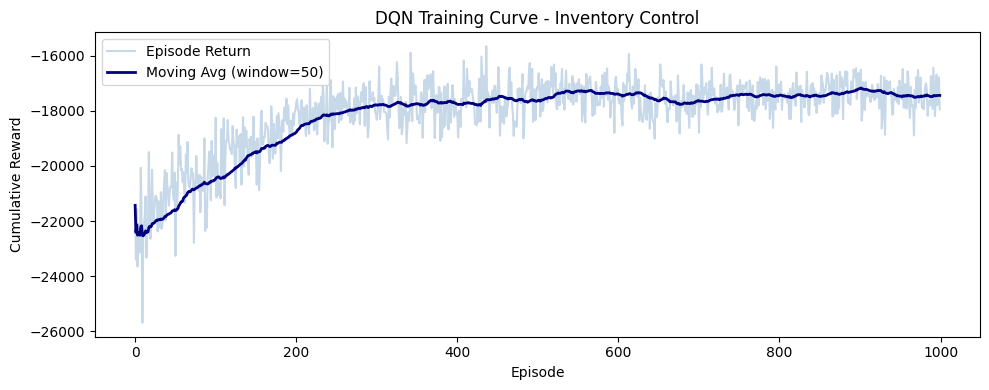

In [7]:
# Moving average (window=50)
window = 50
moving_avg = [np.mean(returns_list[max(0, i-window):i+1]) for i in range(len(returns_list))]

plt.figure(figsize=(10, 4))
plt.plot(returns_list, alpha=0.3, color='steelblue', label='Episode Return')
plt.plot(moving_avg, color='navy', linewidth=2, label=f'Moving Avg (window={window})')
plt.xlabel('Episode')
plt.ylabel('Cumulative Reward')
plt.title('DQN Training Curve - Inventory Control')
plt.legend()
plt.tight_layout()
plt.savefig('dqn_learning_curve.png', dpi=150)
plt.show()

## (6) 테스트 (100 에피소드) + 발주 행동 분석

In [8]:
agent.q.eval()

test_episodes = 100
test_returns = []

# 재고 수준별 발주량 기록
order_by_inventory = {I: [] for I in range(env.I_max + 1)}

for episode in range(test_episodes):
    state = env.reset()
    episode_return = 0
    done = False

    while not done:
        _, I = int(state[0]), int(state[1])
        action = agent.choose_action(state, epsilon=0)  # greedy
        order_by_inventory[I].append(action)

        next_state, reward, done = env.step(action)
        episode_return += reward
        state = next_state

    test_returns.append(episode_return)

print(f"\n[Test] Average Return over {test_episodes} episodes: {np.mean(test_returns):.1f}")
print(f"[Test] Std: {np.std(test_returns):.1f}")


[Test] Average Return over 100 episodes: -16867.5
[Test] Std: 342.3


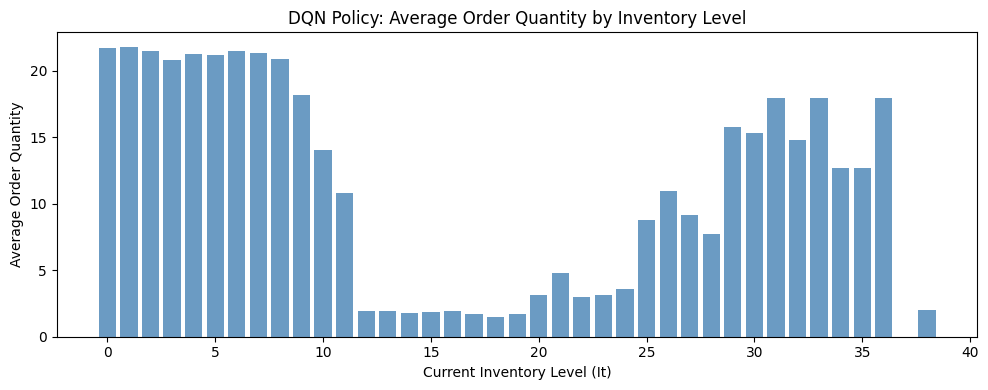


[Policy Analysis] Inventory Level -> Avg Order Quantity
  I= 0 -> avg order = 21.74
  I= 1 -> avg order = 21.82
  I= 2 -> avg order = 21.51
  I= 3 -> avg order = 20.86
  I= 4 -> avg order = 21.25
  I= 5 -> avg order = 21.22
  I= 6 -> avg order = 21.48
  I= 7 -> avg order = 21.38
  I= 8 -> avg order = 20.93
  I= 9 -> avg order = 18.20
  I=10 -> avg order = 14.08
  I=11 -> avg order = 10.82
  I=12 -> avg order = 1.97
  I=13 -> avg order = 1.94
  I=14 -> avg order = 1.79
  I=15 -> avg order = 1.87
  I=16 -> avg order = 1.90
  I=17 -> avg order = 1.69
  I=18 -> avg order = 1.52
  I=19 -> avg order = 1.74
  I=20 -> avg order = 3.14
  I=21 -> avg order = 4.80
  I=22 -> avg order = 3.02
  I=23 -> avg order = 3.16
  I=24 -> avg order = 3.61
  I=25 -> avg order = 8.80
  I=26 -> avg order = 10.96
  I=27 -> avg order = 9.12
  I=28 -> avg order = 7.71
  I=29 -> avg order = 15.75
  I=30 -> avg order = 15.33
  I=31 -> avg order = 18.00
  I=32 -> avg order = 14.80
  I=33 -> avg order = 18.00
  I=34 

In [9]:
# 재고 수준별 평균 발주량 시각화
inventory_levels = []
avg_orders = []

for I in range(env.I_max + 1):
    if order_by_inventory[I]:  # 방문한 상태만
        inventory_levels.append(I)
        avg_orders.append(np.mean(order_by_inventory[I]))

plt.figure(figsize=(10, 4))
plt.bar(inventory_levels, avg_orders, color='steelblue', alpha=0.8)
plt.xlabel('Current Inventory Level (It)')
plt.ylabel('Average Order Quantity')
plt.title('DQN Policy: Average Order Quantity by Inventory Level')
plt.tight_layout()
plt.savefig('dqn_policy_analysis.png', dpi=150)
plt.show()

# 수치 출력
print("\n[Policy Analysis] Inventory Level -> Avg Order Quantity")
for I, q in zip(inventory_levels, avg_orders):
    print(f"  I={I:2d} -> avg order = {q:.2f}")